In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

Loads IMDB and only takes top 10000 most frequent words

In [2]:
max_words = 10000
max_length = 150

(train_data, train_label), (test_data, test_label) = imdb.load_data(num_words=max_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Pad lengths so every review is same length of 150 words

In [3]:
train_data= pad_sequences(train_data, maxlen=max_length)
test_data = pad_sequences(test_data, maxlen=max_length)

print(f"{train_data.shape}")
print(f"{test_data.shape}")

(25000, 150)
(25000, 150)


Create 100 samples for training data

In [4]:
num_training_samples = 100

train_data_100 = train_data[:num_training_samples]
train_label_100 = train_label[:num_training_samples]

print(f"{train_data.shape}")
print(f"{train_label.shape}")

(25000, 150)
(25000,)


Validation of 10000 samples

In [5]:
num_validation_samples = 10000
val_data = train_data[:num_validation_samples]
val_label = train_label[:num_validation_samples]

print(f"{val_data.shape}")
print(f"{val_label.shape}")

(10000, 150)
(10000,)


Embedding layer

In [18]:
inputs = keras.Input(shape=(None,), dtype="int64")
embedding_layer = layers.Embedding(input_dim=max_words, output_dim=100)(inputs)
x = layers.Bidirectional(layers.LSTM(32))(embedding_layer)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint("embeddings_LSTM.keras",
                                    save_best_only=True)
]
history = model.fit(train_data_100, train_label_100,
                    epochs=10,
                    batch_size=32,
                    validation_data=(val_data, val_label),
                    callbacks=callbacks)
model = keras.models.load_model('embeddings_LSTM.keras')
print(f"Test acc: {model.evaluate(test_data, test_label)[1]:.3f}")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, None, 100)      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 64)             │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,034,113 (3.94 MB)

 Trainable params: 1,034,113 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 794ms/step - accuracy: 0.5700 - loss: 0.6917 - val_accuracy: 0.4948 - val_loss: 0.6936
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 656ms/step - accuracy: 0.5900 - loss: 0.6826 - val_accuracy: 0.4947 - val_loss: 0.6946
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 636ms/step - accuracy: 0.5800 - loss: 0.6720 - val_accuracy: 0.4947 - val_loss: 0.6961
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 623ms/step - accuracy: 0.6000 - loss: 0.6667 - val_accuracy: 0.4947 - val_loss: 0.7028
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 625ms/step - accuracy: 0.5800 - loss: 0.6515 - val_accuracy: 0.4947 - val_loss: 0.7029
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 617ms/step - accuracy: 0.5800 - loss: 0.6452 - val_accuracy: 0.4963 - val_loss: 0.6954
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 625ms/step - accuracy: 0.6500 - loss: 0.6288 - val_accuracy: 0.5195 - val_loss: 0.6943
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 635ms/step - accuracy: 0.6800 - loss: 0.6117 - val_accuracy: 0.4959 - val_loss:

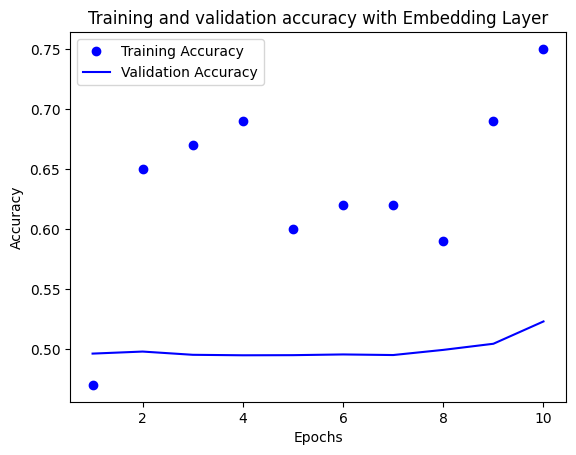

In [7]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
num_epochs = range(1, len(training_accuracy) + 1)


plt.plot(num_epochs, training_accuracy, 'bo', label='Training Accuracy')
plt.plot(num_epochs, validation_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and validation accuracy with Embedding Layer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

GloVe Pretrained word embedding

In [8]:
!wget http://nlp.stanford.edu/data/glove.6B.zip


--2026-04-20 00:43:42--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-20 00:43:42--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-20 00:43:42--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [11]:
!unzip -q glove.6B.zip

In [12]:

glove_path = "glove.6B.100d.txt"
embeddings_index = {}
with open(glove_path) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, 'f', sep=' ')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

word_index = imdb.get_word_index()


embedding_dim = 100
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    if i < max_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


Found 400000 word vectors.
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Pretrained Model

In [20]:
inputs_glove = keras.Input(shape=(None,), dtype="int64")
embedding_layer_glove = layers.Embedding(
    input_dim=max_words,
    output_dim=embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,
)(inputs_glove)

x_glove = layers.Bidirectional(layers.LSTM(32))(embedding_layer_glove)
x_glove = layers.Dropout(0.5)(x_glove)
outputs_glove = layers.Dense(1, activation="sigmoid")(x_glove)
model_glove = keras.Model(inputs_glove, outputs_glove)

model_glove.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_glove.summary()

callbacks_glove = [
    keras.callbacks.ModelCheckpoint("glove_LSTM.keras", save_best_only=True)
]

history_glove = model_glove.fit(
    train_data_100, train_label_100,
    epochs=10,
    batch_size=32,
    validation_data=(val_data, val_label),
    callbacks=callbacks_glove
)


model_glove = keras.models.load_model('glove_LSTM.keras')
print(f"Test acc with GloVe: {model_glove.evaluate(test_data, test_label)[1]:.3f}")

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, None, 100)      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 64)             │        34,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,034,113 (3.94 MB)

 Trainable params: 34,113 (133.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5000 - loss: 0.7065 - val_accuracy: 0.4956 - val_loss: 0.7071
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5500 - loss: 0.6705 - val_accuracy: 0.5047 - val_loss: 0.6952
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 653ms/step - accuracy: 0.5300 - loss: 0.6887 - val_accuracy: 0.4983 - val_loss: 0.7009
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 658ms/step - accuracy: 0.5800 - loss: 0.6607 - val_accuracy: 0.5046 - val_loss: 0.6953
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 626ms/step - accuracy: 0.5800 - loss: 0.6642 - val_accuracy: 0.5003 - val_loss: 0.6990
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 644ms/step - accuracy: 0.6000 - loss: 0.6516 - val_accuracy: 0.5033 - val_loss: 0.6967
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 660ms/step - accuracy: 0.6700 - loss: 0.6493 - val_accuracy: 0.5008 - val_loss: 0.7011
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 629ms/step - accuracy: 0.6100 - loss: 0.6360 - val_accuracy: 0.5032 - val_loss: 0.696

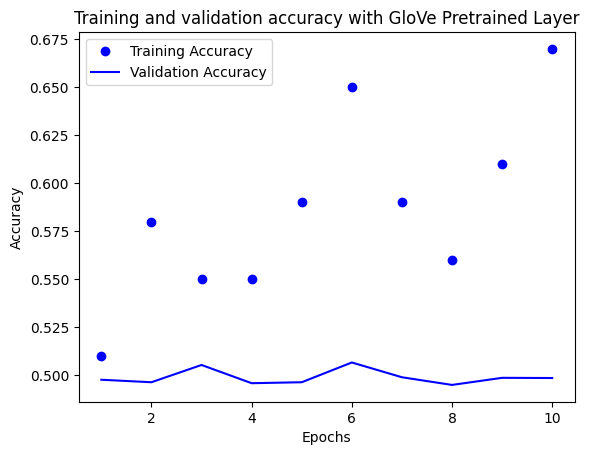

In [14]:
training_accuracy = history_glove.history['accuracy']
validation_accuracy = history_glove.history['val_accuracy']
training_loss = history_glove.history['loss']
validation_loss = history_glove.history['val_loss']
num_epochs = range(1, len(training_accuracy) + 1)


plt.plot(num_epochs, training_accuracy, 'bo', label='Training Accuracy')
plt.plot(num_epochs, validation_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and validation accuracy with GloVe Pretrained Layer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Increasing Training samples




Shape of 500 training samples data: (500, 150)
Shape of 500 training samples labels: (500,)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, None, 100)      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, None, 64)       │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,449 (3.98 MB)

 Trainable params: 1,044,449 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 280ms/step - accuracy: 0.5000 - loss: 0.6947 - val_accuracy: 0.5577 - val_loss: 0.6915
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.5780 - loss: 0.6882 - val_accuracy: 0.5744 - val_loss: 0.6892
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.5840 - loss: 0.6840 - val_accuracy: 0.6056 - val_loss: 0.6810
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - accuracy: 0.7060 - loss: 0.6362 - val_accuracy: 0.6680 - val_loss: 0.6192
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.7780 - loss: 0.5341 - val_accuracy: 0.6655 - val_loss: 0.6114
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.8440 - loss: 0.4538 - val_accuracy: 0.6808 - val_loss: 0.6209
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.8920 - loss: 0.3152 - val_accuracy: 0.7394 - val_loss: 0.5565
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.9640 - loss: 0.1627 - val_accuracy: 0.

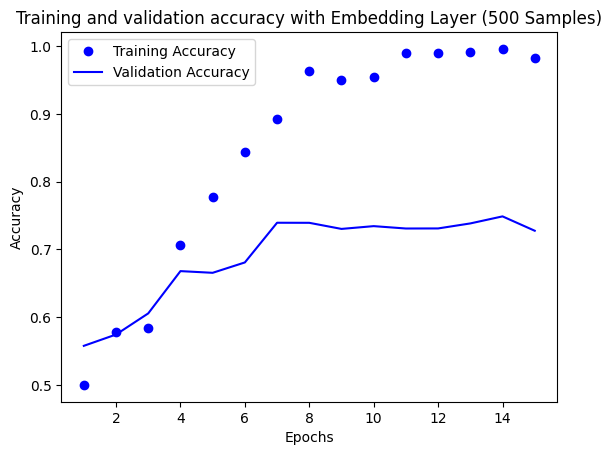

In [15]:
num_training_samples_500 = 500

train_data_500 = train_data[:num_training_samples_500]
train_label_500 = train_label[:num_training_samples_500]



inputs_500 = keras.Input(shape=(None,), dtype="int64")
embedding_layer_500 = layers.Embedding(input_dim=max_words, output_dim=100)(inputs_500)
x_500 = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(embedding_layer_500)
x_500 = layers.Dropout(0.5)(x_500)
x_500 = layers.Bidirectional(layers.LSTM(16))(x_500)
x_500 = layers.Dropout(0.5)(x_500)
outputs_500 = layers.Dense(1, activation="sigmoid")(x_500)
model_500_samples = keras.Model(inputs_500, outputs_500)

model_500_samples.compile(optimizer="rmsprop",
                          loss="binary_crossentropy",
                          metrics=["accuracy"])
model_500_samples.summary()

callbacks_500 = [
    keras.callbacks.ModelCheckpoint("embeddings_LSTM_500_samples.keras",
                                    save_best_only=True)
]

history_500_samples = model_500_samples.fit(train_data_500, train_label_500,
                                            epochs=15,
                                            batch_size=32,
                                            validation_data=(val_data, val_label),
                                            callbacks=callbacks_500)

model_500_samples = keras.models.load_model('embeddings_LSTM_500_samples.keras')
print(f"Test acc with 500 samples: {model_500_samples.evaluate(test_data, test_label)[1]:.3f}")

training_accuracy = history_500_samples.history['accuracy']
validation_accuracy = history_500_samples.history['val_accuracy']
training_loss = history_500_samples.history['loss']
validation_loss = history_500_samples.history['val_loss']
num_epochs = range(1, len(training_accuracy) + 1)


plt.plot(num_epochs, training_accuracy, 'bo', label='Training Accuracy')
plt.plot(num_epochs, validation_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and validation accuracy with Embedding Layer (500 Samples)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

500 Pretrained

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (None, None, 100)      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, None, 64)       │        34,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 32)             │        10,368 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,449 (3.98 MB)

 Trainable params: 44,449 (173.63 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 365ms/step - accuracy: 0.4920 - loss: 0.7109 - val_accuracy: 0.5107 - val_loss: 0.6930
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - accuracy: 0.5260 - loss: 0.6957 - val_accuracy: 0.5045 - val_loss: 0.6974
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.5060 - loss: 0.7010 - val_accuracy: 0.5118 - val_loss: 0.6930
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 330ms/step - accuracy: 0.5340 - loss: 0.6918 - val_accuracy: 0.5252 - val_loss: 0.6910
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 356ms/step - accuracy: 0.5320 - loss: 0.6928 - val_accuracy: 0.5318 - val_loss: 0.6908
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.5480 - loss: 0.6833 - val_accuracy: 0.4994 - val_loss: 0.7003
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.5640 - loss: 0.6745 - val_accuracy: 0.4989 - val_loss: 0.7244
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 324ms/step - accuracy: 0.5900 - loss: 0.6743 - val_accuracy: 0.

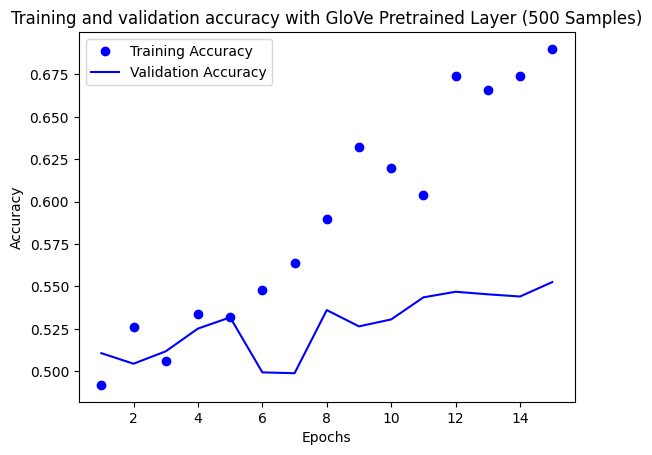

In [21]:
num_training_samples_500 = 500

train_data_500 = train_data[:num_training_samples_500]
train_label_500 = train_label[:num_training_samples_500]


inputs_glove_500 = keras.Input(shape=(None,), dtype="int64")
embedding_layer_glove_500 = layers.Embedding(
    input_dim=max_words,
    output_dim=embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,
)(inputs_glove_500)

x_glove_500 = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(embedding_layer_glove_500)
x_glove_500 = layers.Dropout(0.5)(x_glove_500)
x_glove_500 = layers.Bidirectional(layers.LSTM(16))(x_glove_500)
x_glove_500 = layers.Dropout(0.5)(x_glove_500)
outputs_glove_500 = layers.Dense(1, activation="sigmoid")(x_glove_500)
model_glove_500_samples = keras.Model(inputs_glove_500, outputs_glove_500)

model_glove_500_samples.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model_glove_500_samples.summary()

callbacks_glove_500 = [
    keras.callbacks.ModelCheckpoint("glove_LSTM_500_samples.keras", save_best_only=True)
]

history_glove_500_samples = model_glove_500_samples.fit(
    train_data_500, train_label_500,
    epochs=15,
    batch_size=32,
    validation_data=(val_data, val_label),
    callbacks=callbacks_glove_500
)

model_glove_500_samples = keras.models.load_model('glove_LSTM_500_samples.keras')
print(f"Test acc with GloVe and 500 samples: {model_glove_500_samples.evaluate(test_data, test_label)[1]:.3f}")


training_accuracy = history_glove_500_samples.history['accuracy']
validation_accuracy = history_glove_500_samples.history['val_accuracy']
training_loss = history_glove_500_samples.history['loss']
validation_loss = history_glove_500_samples.history['val_loss']
num_epochs = range(1, len(training_accuracy) + 1)


plt.plot(num_epochs, training_accuracy, 'bo', label='Training Accuracy')
plt.plot(num_epochs, validation_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and validation accuracy with GloVe Pretrained Layer (500 Samples)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

2000 Training samples

Shape of 2000 training samples data: (2000, 150)
Shape of 2000 training samples labels: (2000,)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, None, 100)      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, None, 64)       │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,449 (3.98 MB)

 Trainable params: 1,044,449 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.5200 - loss: 0.6930 - val_accuracy: 0.5142 - val_loss: 0.6909
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.5830 - loss: 0.6776 - val_accuracy: 0.6980 - val_loss: 0.6158
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.7610 - loss: 0.5278 - val_accuracy: 0.7566 - val_loss: 0.4974
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.8565 - loss: 0.3689 - val_accuracy: 0.8106 - val_loss: 0.4414
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.8955 - loss: 0.2882 - val_accuracy: 0.8338 - val_loss: 0.4220
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9395 - loss: 0.1780 - val_accuracy: 0.7864 - val_loss: 0.6028
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9565 - loss: 0.1454 - val_accuracy: 0.7794 - val_loss: 0.6213
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9755 - loss: 0.0980 - val_accuracy: 0.8248 - v

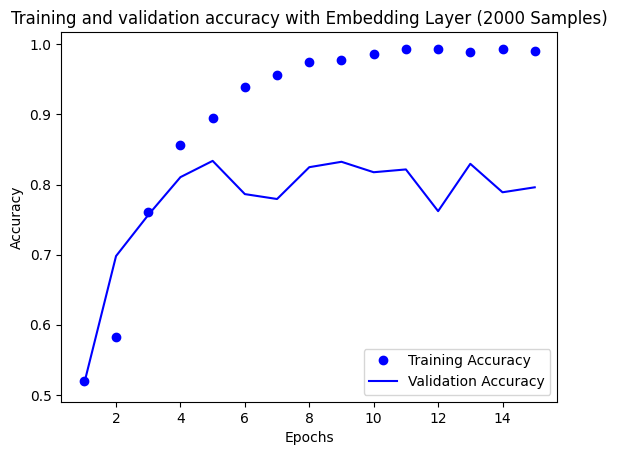

In [16]:
num_training_samples_2000 = 2000

train_data_2000 = train_data[:num_training_samples_2000]
train_label_2000 = train_label[:num_training_samples_2000]


inputs_2000 = keras.Input(shape=(None,), dtype="int64")
embedding_layer_2000 = layers.Embedding(input_dim=max_words, output_dim=100)(inputs_2000)
x_2000 = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(embedding_layer_2000)
x_2000 = layers.Dropout(0.5)(x_2000)
x_2000 = layers.Bidirectional(layers.LSTM(16))(x_2000)
x_2000 = layers.Dropout(0.5)(x_2000)
outputs_2000 = layers.Dense(1, activation="sigmoid")(x_2000)
model_2000_samples = keras.Model(inputs_2000, outputs_2000)

model_2000_samples.compile(optimizer="rmsprop",
                            loss="binary_crossentropy",
                            metrics=["accuracy"])
model_2000_samples.summary()

callbacks_2000 = [
    keras.callbacks.ModelCheckpoint("embeddings_LSTM_2000_samples.keras",
                                    save_best_only=True)
]

history_2000_samples = model_2000_samples.fit(train_data_2000, train_label_2000,
                                              epochs=15,
                                              batch_size=32,
                                              validation_data=(val_data, val_label),
                                              callbacks=callbacks_2000)

model_2000_samples = keras.models.load_model('embeddings_LSTM_2000_samples.keras')
print(f"Test acc with 2000 samples: {model_2000_samples.evaluate(test_data, test_label)[1]:.3f}")


training_accuracy = history_2000_samples.history['accuracy']
validation_accuracy = history_2000_samples.history['val_accuracy']
training_loss = history_2000_samples.history['loss']
validation_loss = history_2000_samples.history['val_loss']
num_epochs = range(1, len(training_accuracy) + 1)


plt.plot(num_epochs, training_accuracy, 'bo', label='Training Accuracy')
plt.plot(num_epochs, validation_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and validation accuracy with Embedding Layer (2000 Samples)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

pretrained 2000 samples

Shape of 2000 training samples data: (2000, 150)
Shape of 2000 training samples labels: (2000,)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, None, 100)      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, None, 64)       │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,449 (3.98 MB)

 Trainable params: 44,449 (173.63 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.4890 - loss: 0.7015 - val_accuracy: 0.5196 - val_loss: 0.6917
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.5210 - loss: 0.6958 - val_accuracy: 0.5299 - val_loss: 0.6902
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.5425 - loss: 0.6891 - val_accuracy: 0.5285 - val_loss: 0.6892
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.5545 - loss: 0.6861 - val_accuracy: 0.5234 - val_loss: 0.6892
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.5535 - loss: 0.6788 - val_accuracy: 0.5225 - val_loss: 0.6915
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.5755 - loss: 0.6749 - val_accuracy: 0.5549 - val_loss: 0.6811
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.5890 - loss: 0.6700 - val_accuracy: 0.5811 - val_loss: 0.6741
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.6070 - loss: 0.6588 - val_accuracy: 0.5920 -

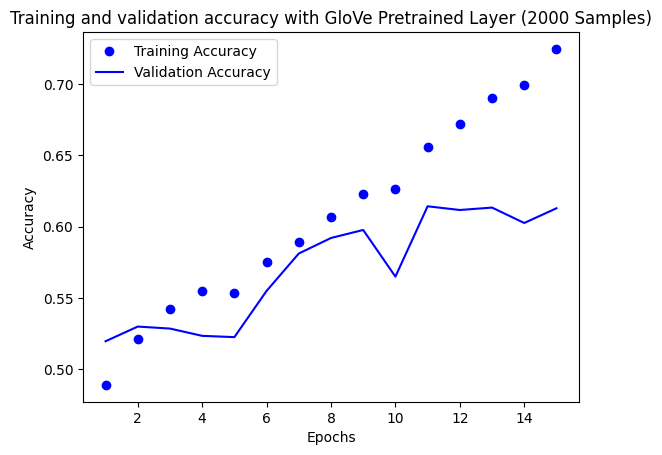

In [17]:
num_training_samples_2000 = 2000

train_data_2000 = train_data[:num_training_samples_2000]
train_label_2000 = train_label[:num_training_samples_2000]

print(f"Shape of 2000 training samples data: {train_data_2000.shape}")
print(f"Shape of 2000 training samples labels: {train_label_2000.shape}")

inputs_glove_2000 = keras.Input(shape=(None,), dtype="int64")
embedding_layer_glove_2000 = layers.Embedding(
    input_dim=max_words,
    output_dim=embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,
)(inputs_glove_2000)

x_glove_2000 = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(embedding_layer_glove_2000)
x_glove_2000 = layers.Dropout(0.5)(x_glove_2000)
x_glove_2000 = layers.Bidirectional(layers.LSTM(16))(x_glove_2000)
x_glove_2000 = layers.Dropout(0.5)(x_glove_2000)
outputs_glove_2000 = layers.Dense(1, activation="sigmoid")(x_glove_2000)
model_glove_2000_samples = keras.Model(inputs_glove_2000, outputs_glove_2000)

model_glove_2000_samples.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model_glove_2000_samples.summary()

callbacks_glove_2000 = [
    keras.callbacks.ModelCheckpoint("glove_LSTM_2000_samples.keras", save_best_only=True)
]

history_glove_2000_samples = model_glove_2000_samples.fit(
    train_data_2000, train_label_2000,
    epochs=15,
    batch_size=32,
    validation_data=(val_data, val_label),
    callbacks=callbacks_glove_2000
)

model_glove_2000_samples = keras.models.load_model('glove_LSTM_2000_samples.keras')
print(f"Test acc with GloVe and 2000 samples: {model_glove_2000_samples.evaluate(test_data, test_label)[1]:.3f}")


training_accuracy = history_glove_2000_samples.history['accuracy']
validation_accuracy = history_glove_2000_samples.history['val_accuracy']
training_loss = history_glove_2000_samples.history['loss']
validation_loss = history_glove_2000_samples.history['val_loss']
num_epochs = range(1, len(training_accuracy) + 1)


plt.plot(num_epochs, training_accuracy, 'bo', label='Training Accuracy')
plt.plot(num_epochs, validation_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and validation accuracy with GloVe Pretrained Layer (2000 Samples)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()